In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans , DBSCAN

In [7]:
df=pd.read_csv('diabetes_dataset.csv')

In [8]:
df.sample(10)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
56435,2019,Male,51.0,Nebraska,0,0,0,1,0,0,0,never,23.67,6.6,90,0
2088,2015,Female,45.0,Alaska,0,0,0,1,0,0,0,never,24.97,5.0,160,0
33839,2016,Male,10.0,Kansas,1,0,0,0,0,0,0,No Info,27.32,4.0,155,0
59001,2019,Female,24.0,Nevada,0,0,0,1,0,0,0,No Info,27.32,6.2,90,0
55138,2019,Female,57.0,Montana,1,0,0,0,0,0,0,No Info,35.14,6.5,126,0
35819,2015,Female,57.0,Kentucky,0,0,0,1,0,0,0,No Info,27.32,4.0,126,0
49286,2019,Male,47.0,Minnesota,0,1,0,0,0,0,0,never,31.42,7.5,130,1
55150,2019,Male,70.0,Montana,0,0,1,0,0,0,0,current,29.01,7.5,140,1
78580,2016,Male,47.0,Pennsylvania,0,0,0,1,0,0,1,never,31.17,6.5,80,0
37521,2019,Female,22.0,Kentucky,0,0,1,0,0,0,0,not current,20.01,6.0,126,0


In [11]:
df.isnull().sum().sort_values(ascending=False)

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [13]:
df.shape

(100000, 16)

In [14]:
num=df.select_dtypes(exclude='object')
cat=df.select_dtypes(include='object')

In [15]:
num.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [16]:
cat.describe()

,gender,location,smoking_history
count,100000,100000,100000
unique,3,55,6
top,Female,Kentucky,No Info
freq,58552,2038,35816


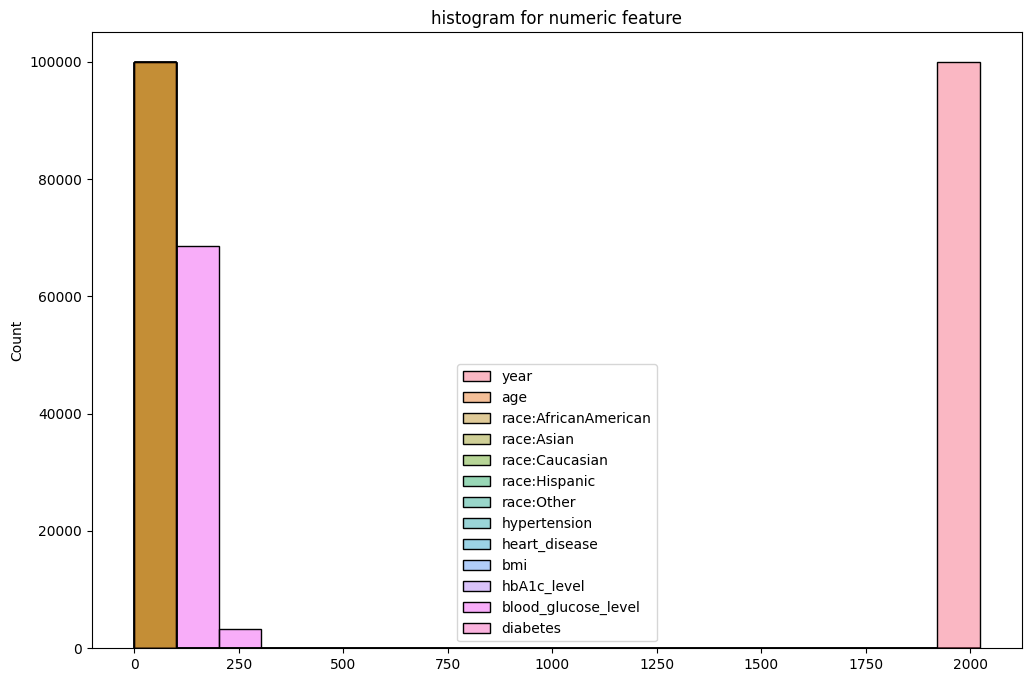

In [21]:
plt.figure(figsize=(12,8))
sns.histplot(num,bins=20,kde=False)
plt.title("histogram for numeric feature")
plt.show()

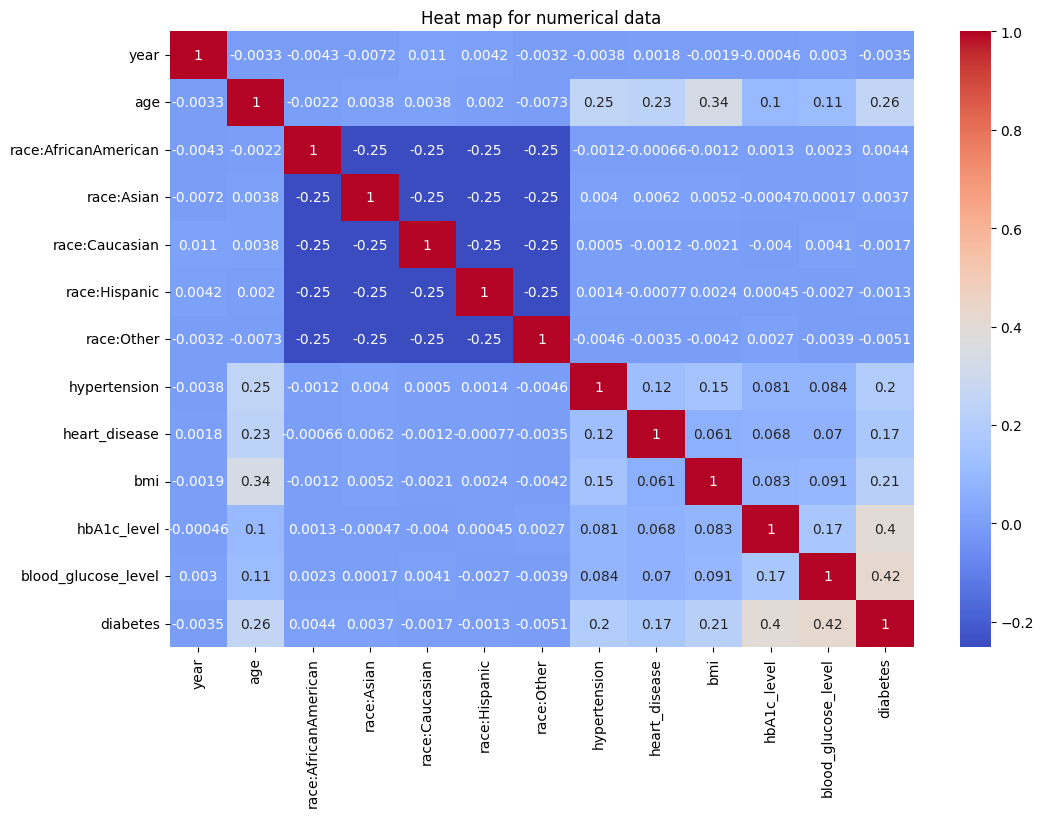

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(num.corr(),annot=True,cmap='coolwarm')
plt.title("Heat map for numerical data")
plt.show()

In [ ]:

sns.pairplot(data=num, hue='diabetes')
plt.show()


KeyboardInterrupt: 